<a href="https://colab.research.google.com/github/ajaykumar080286/MachineLearning/blob/main/31_gradient_descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification

In [2]:
X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=20)

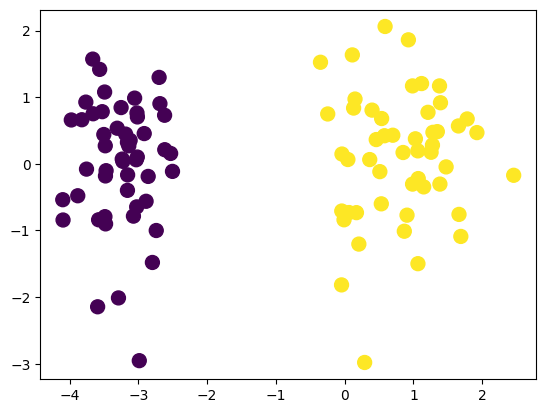

In [3]:
plt.scatter(X[:,0],X[:,1], c=y, s=100)

In [4]:
lor = LogisticRegression(penalty=None,solver='sag')
lor.fit(X,y)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(penalty=None, solver='sag')

In [5]:
coef_=lor.coef_

In [6]:
intercept_=lor.intercept_

In [7]:
m=-(coef_[0][0]/coef_[0][1])

In [8]:
b=-(intercept_[0]/coef_[0][1])

In [10]:
x_input = np.linspace(-3,3,100)
y_input = m*x_input + b

In [47]:
def gd(X,y):

  X = np.insert(X,0,1,axis=1)
  weights = np.ones(X.shape[1])
  lr = 0.5

  for i in range(5000):
    y_hat=sigmoid(np.dot(X,weights))
    weights=weights+lr*(np.dot((y-y_hat),X)/X.shape[0])
  return weights[1:],weights[0]


In [48]:
def sigmoid(z):
    return 1/(1 + np.exp(-z))

In [49]:
coef_,intercept_ = gd(X,y)

In [50]:
coef_

array([4.83926872, 0.21182255])

In [51]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

In [52]:
x_input1 = np.linspace(-3,3,100)
y_input1 = m*x_input1 + b

(-3.0, 2.0)

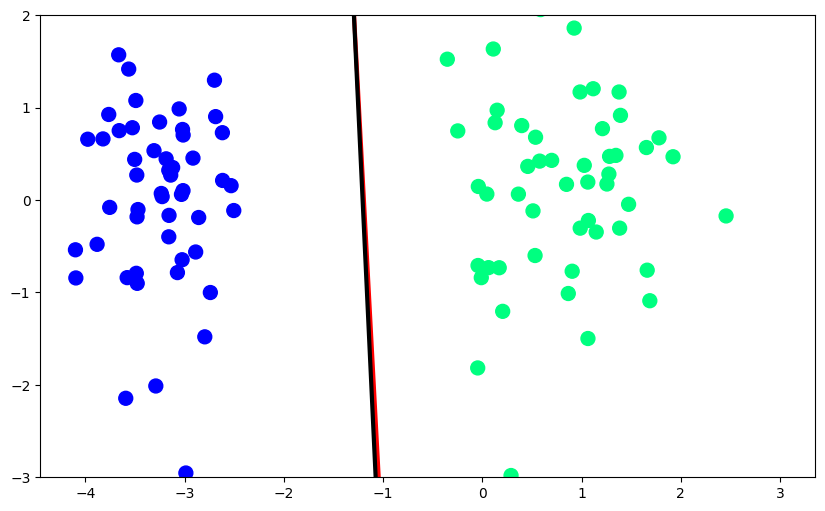

In [53]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.plot(x_input1,y_input1,color='black',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)